In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
import seaborn as sns

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/competitions/playground-series-s6e2/sample_submission.csv
/kaggle/input/competitions/playground-series-s6e2/train.csv
/kaggle/input/competitions/playground-series-s6e2/test.csv


In [2]:
heart_data  = pd.read_csv('/kaggle/input/competitions/playground-series-s6e2/train.csv', index_col=0)
test_data = pd.read_csv('/kaggle/input/competitions/playground-series-s6e2/test.csv', index_col=0)

In [3]:
heart_data.shape

(630000, 14)

In [4]:
heart_data.head()

,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium,Heart Disease
id,,,,,,,,,,,,,,
0,58,1,4,152,239,0,0,158,1,3.6,2,2,7,Presence
1,52,1,1,125,325,0,2,171,0,0.0,1,0,3,Absence
2,56,0,2,160,188,0,2,151,0,0.0,1,0,3,Absence
3,44,0,3,134,229,0,2,150,0,1.0,2,0,3,Absence
4,58,1,4,140,234,0,2,125,1,3.8,2,3,3,Presence


In [5]:
heart_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 630000 entries, 0 to 629999
Data columns (total 14 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   Age                      630000 non-null  int64  
 1   Sex                      630000 non-null  int64  
 2   Chest pain type          630000 non-null  int64  
 3   BP                       630000 non-null  int64  
 4   Cholesterol              630000 non-null  int64  
 5   FBS over 120             630000 non-null  int64  
 6   EKG results              630000 non-null  int64  
 7   Max HR                   630000 non-null  int64  
 8   Exercise angina          630000 non-null  int64  
 9   ST depression            630000 non-null  float64
 10  Slope of ST              630000 non-null  int64  
 11  Number of vessels fluro  630000 non-null  int64  
 12  Thallium                 630000 non-null  int64  
 13  Heart Disease            630000 non-null  object 
dtypes: float6

In [6]:
heart_data.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,630000.0,54.136706,8.256301,29.0,48.0,54.0,60.0,77.0
Sex,630000.0,0.714735,0.451541,0.0,0.0,1.0,1.0,1.0
Chest pain type,630000.0,3.312752,0.851615,1.0,3.0,4.0,4.0,4.0
BP,630000.0,130.497433,14.975802,94.0,120.0,130.0,140.0,200.0
Cholesterol,630000.0,245.011814,33.681581,126.0,223.0,243.0,269.0,564.0
FBS over 120,630000.0,0.079987,0.271274,0.0,0.0,0.0,0.0,1.0
EKG results,630000.0,0.981660,0.998783,0.0,0.0,0.0,2.0,2.0
Max HR,630000.0,152.816763,19.112927,71.0,142.0,157.0,166.0,202.0
Exercise angina,630000.0,0.273725,0.445870,0.0,0.0,0.0,1.0,1.0
ST depression,630000.0,0.716028,0.948472,0.0,0.0,0.1,1.4,6.2


In [7]:
heart_data.isna().sum()

Age                        0
Sex                        0
Chest pain type            0
BP                         0
Cholesterol                0
FBS over 120               0
EKG results                0
Max HR                     0
Exercise angina            0
ST depression              0
Slope of ST                0
Number of vessels fluro    0
Thallium                   0
Heart Disease              0
dtype: int64

array([[<Axes: title={'center': 'Age'}>, <Axes: title={'center': 'Sex'}>,
        <Axes: title={'center': 'Chest pain type'}>,
        <Axes: title={'center': 'BP'}>],
       [<Axes: title={'center': 'Cholesterol'}>,
        <Axes: title={'center': 'FBS over 120'}>,
        <Axes: title={'center': 'EKG results'}>,
        <Axes: title={'center': 'Max HR'}>],
       [<Axes: title={'center': 'Exercise angina'}>,
        <Axes: title={'center': 'ST depression'}>,
        <Axes: title={'center': 'Slope of ST'}>,
        <Axes: title={'center': 'Number of vessels fluro'}>],
       [<Axes: title={'center': 'Thallium'}>, <Axes: >, <Axes: >,
        <Axes: >]], dtype=object)

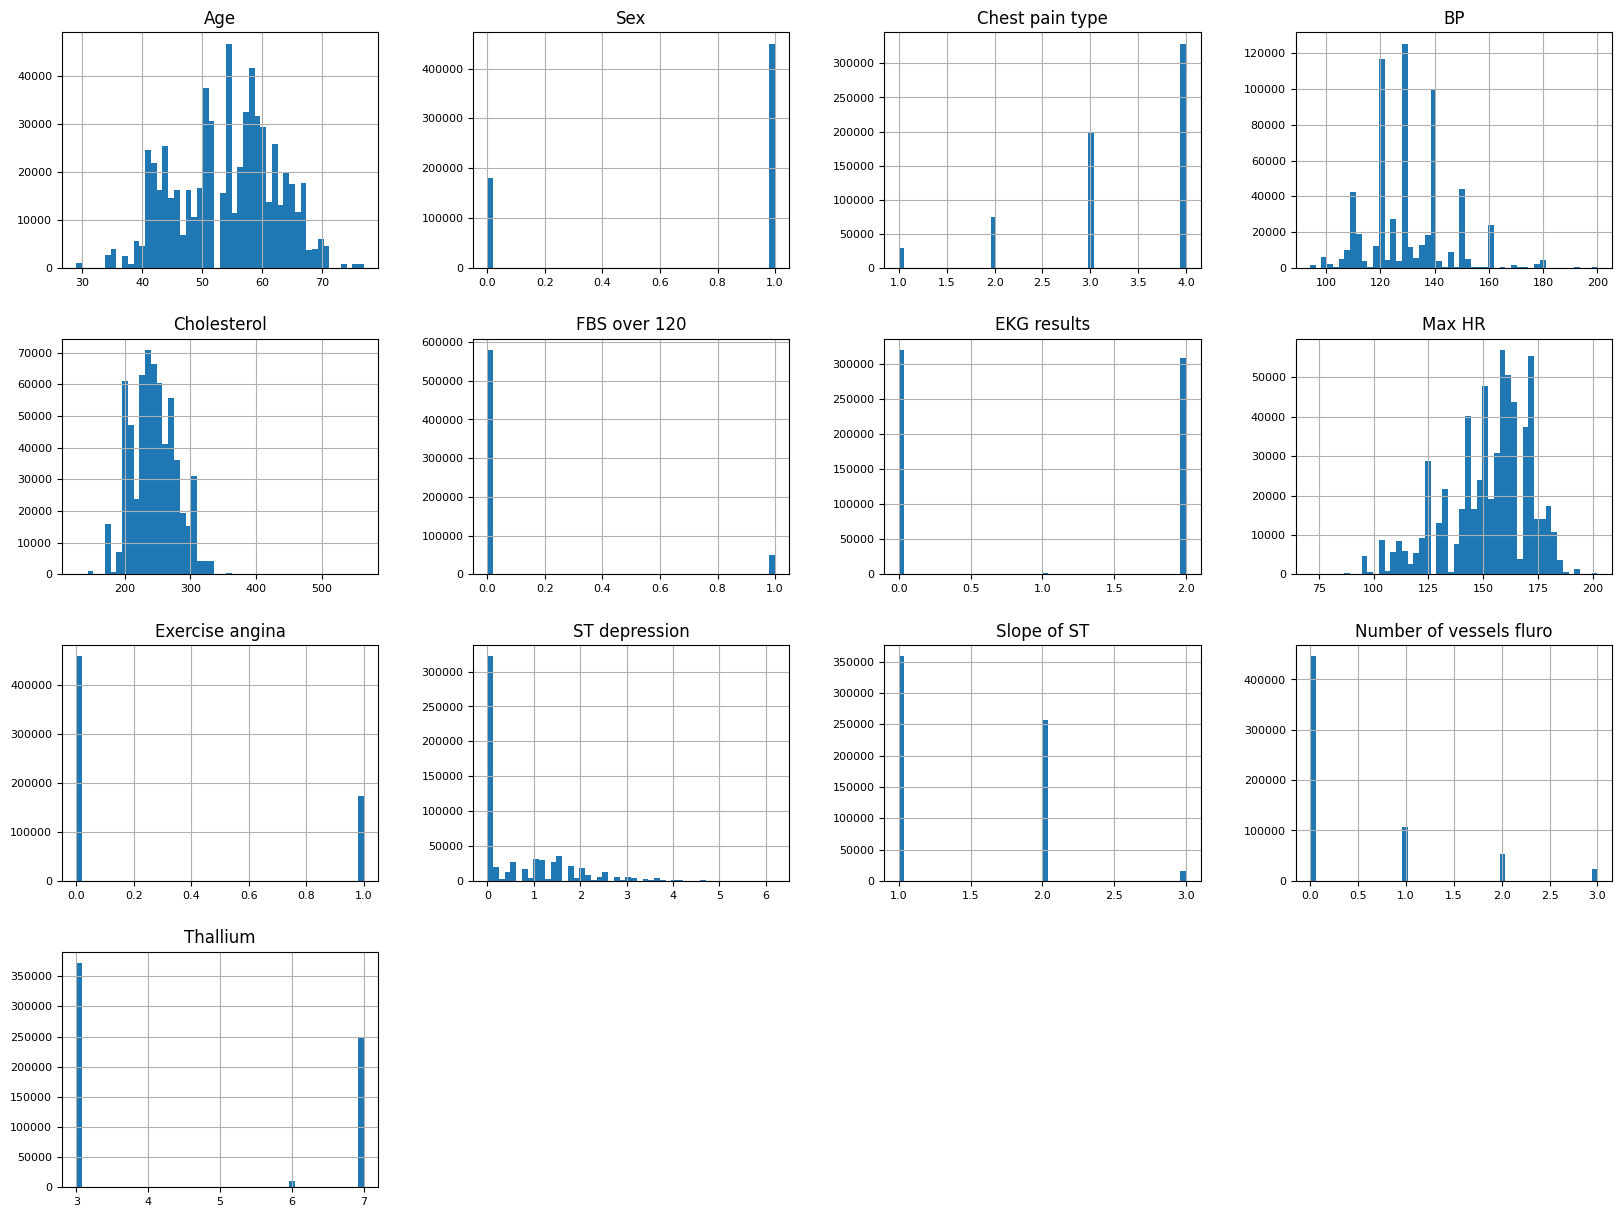

In [8]:
heart_data.hist(figsize=(20, 15), bins=50, xlabelsize=8, ylabelsize=8)

In [9]:
heart_data.describe(include='object').T

,count,unique,top,freq
Heart Disease,630000,2,Absence,347546


In [10]:
heart_data['Heart Disease'].value_counts()

Heart Disease
Absence     347546
Presence    282454
Name: count, dtype: int64

<Axes: xlabel='Heart Disease', ylabel='count'>

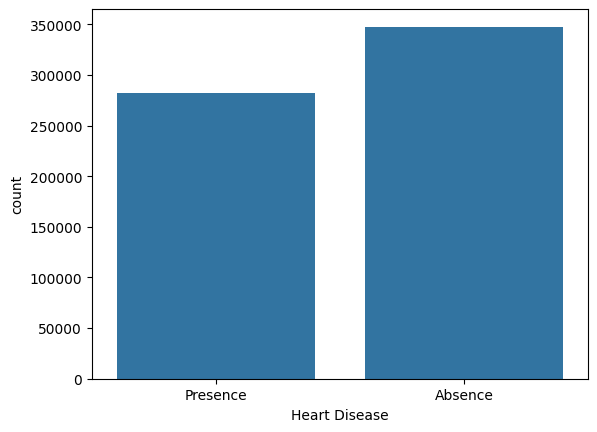

In [11]:
sns.countplot(x='Heart Disease', data=heart_data)

Outlier Detection

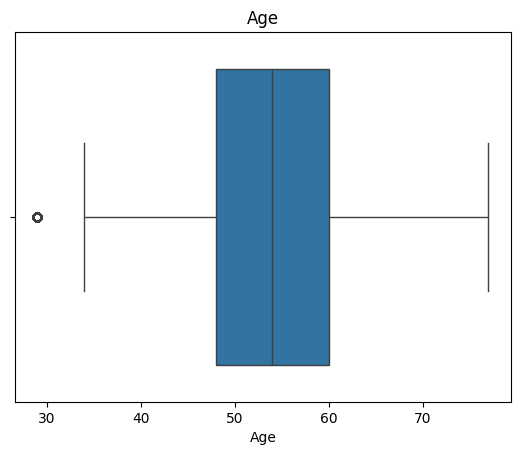

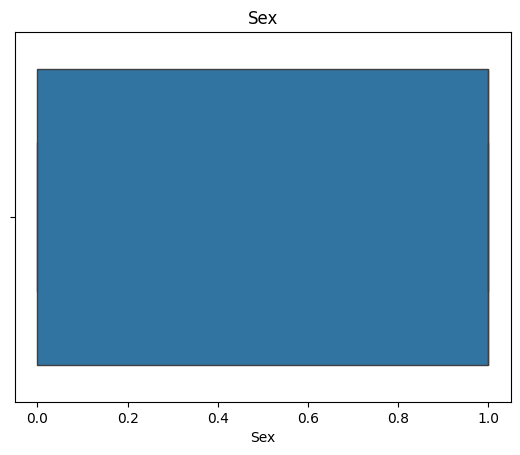

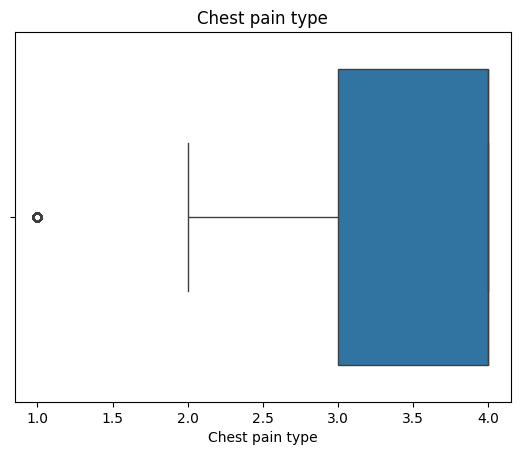

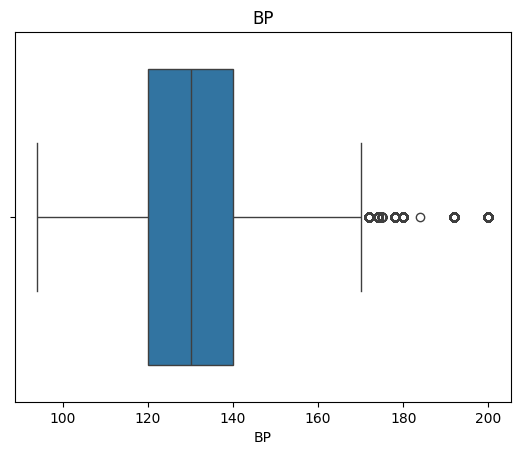

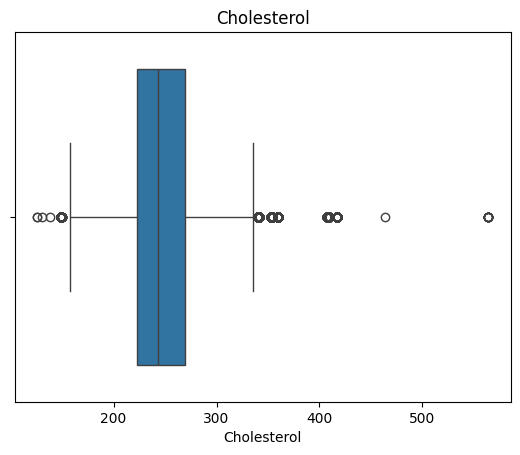

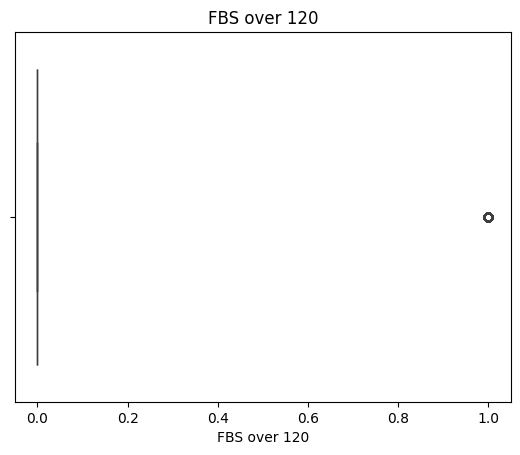

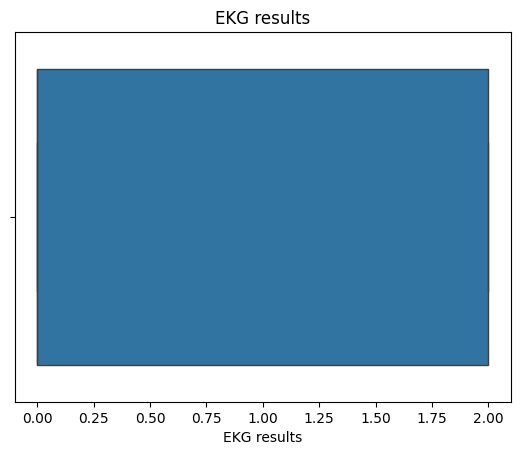

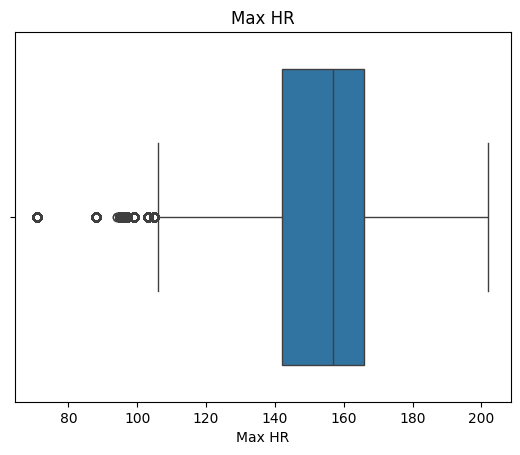

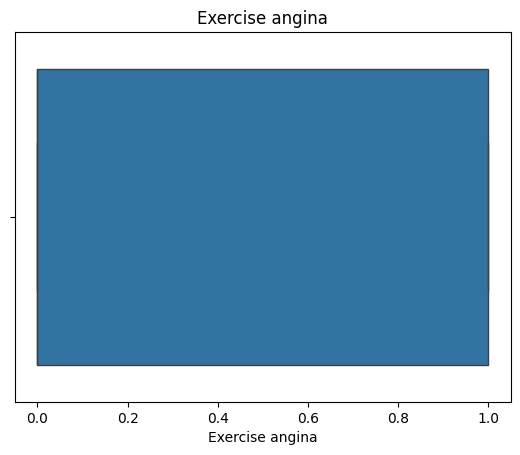

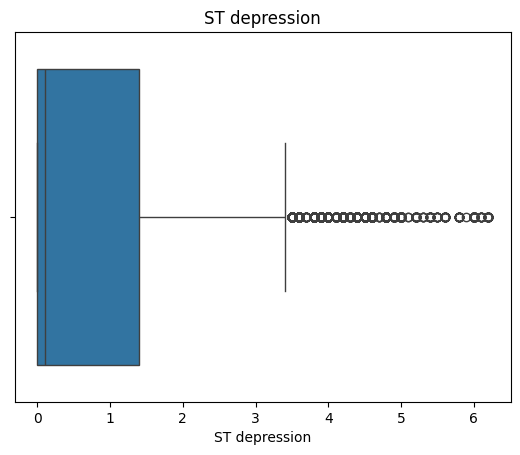

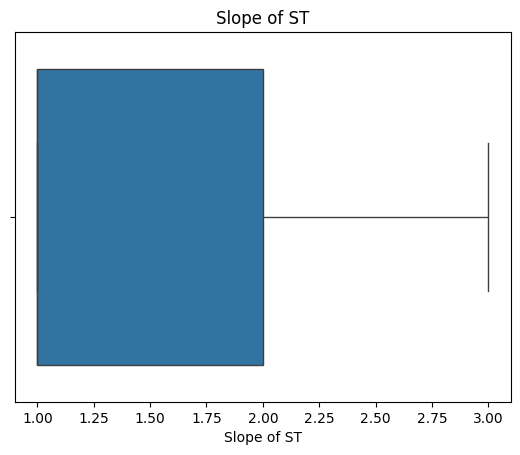

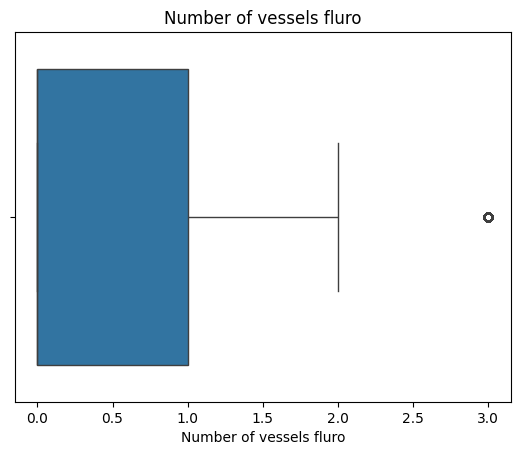

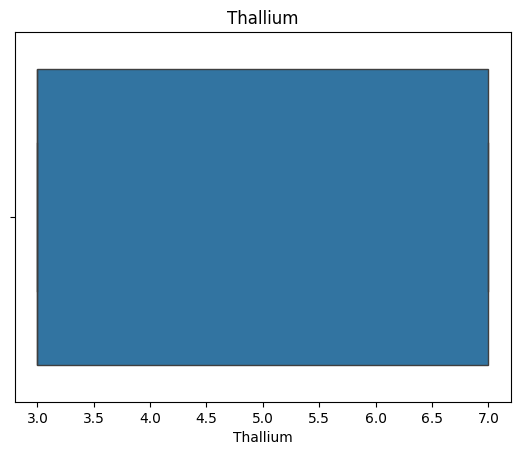

In [12]:
for col in heart_data.columns:
    if col != 'Heart Disease':
        sns.boxplot(x=heart_data[col])
        plt.title(col)
        plt.show()

Boxplot by class

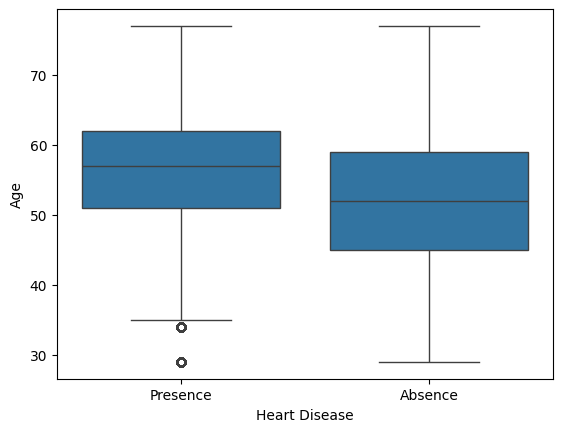

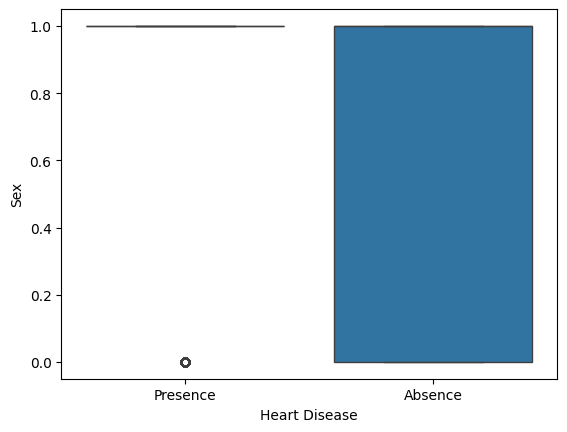

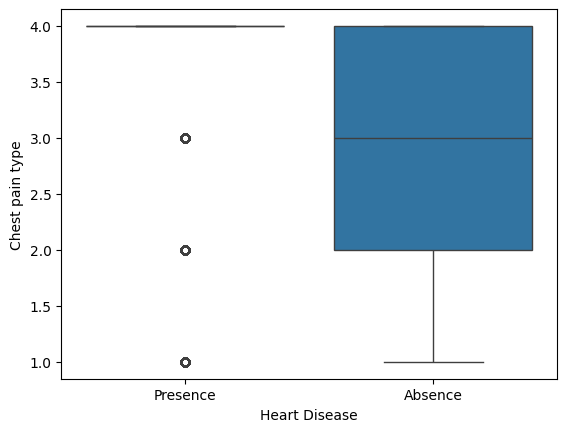

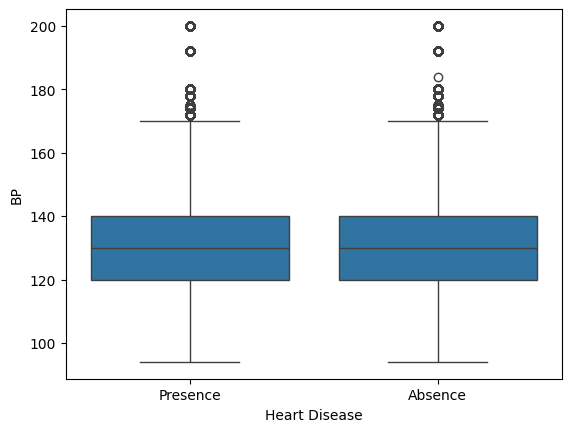

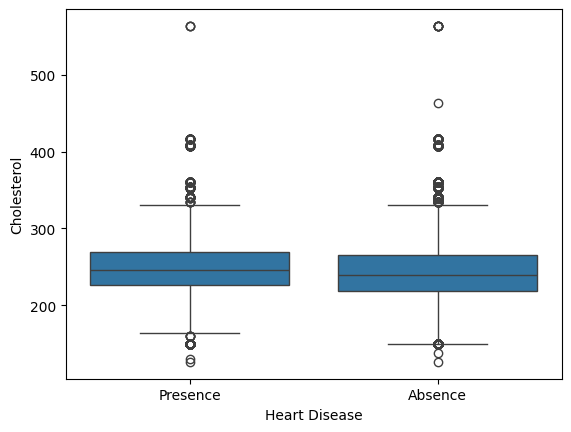

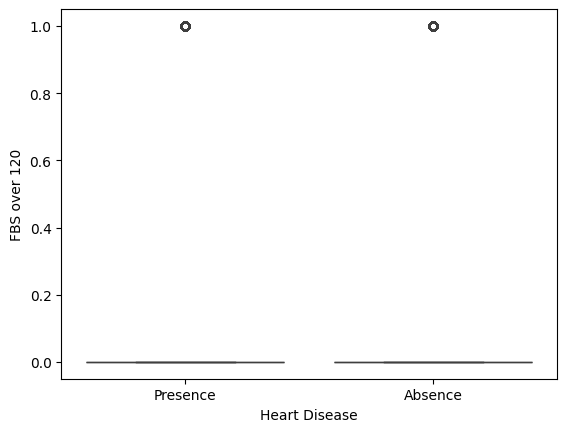

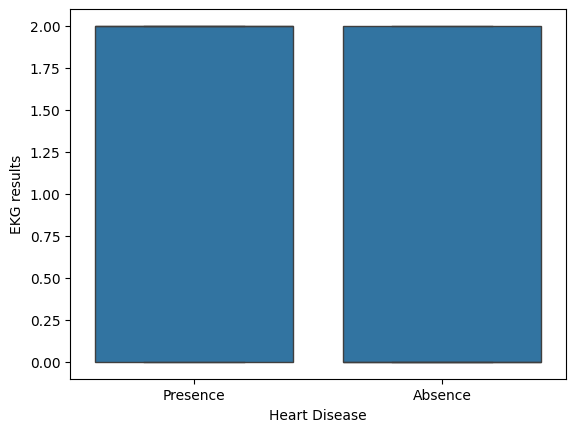

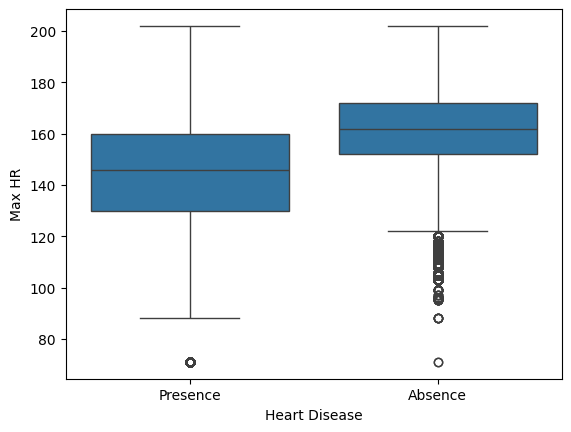

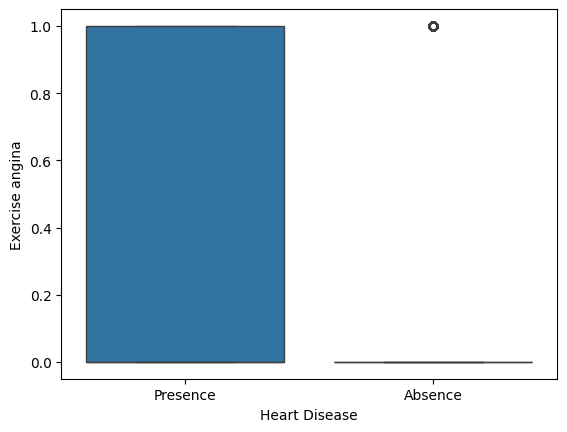

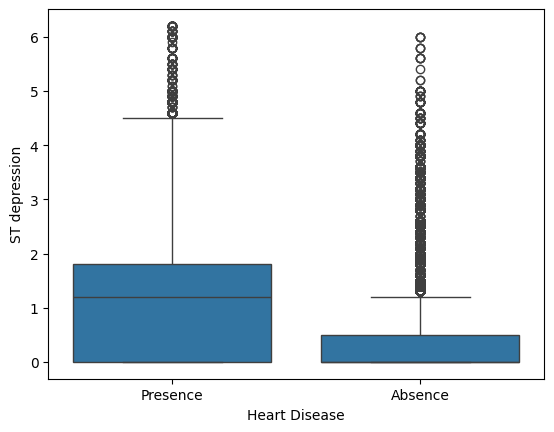

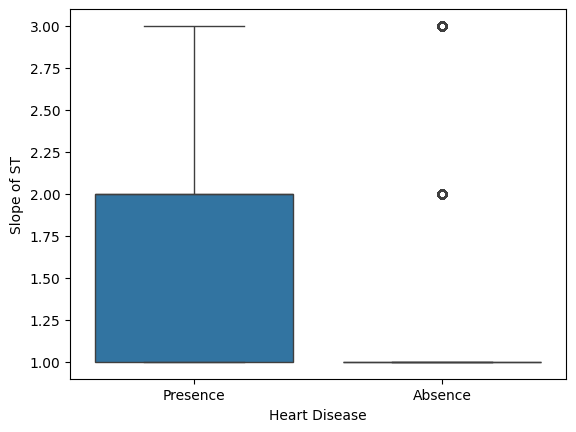

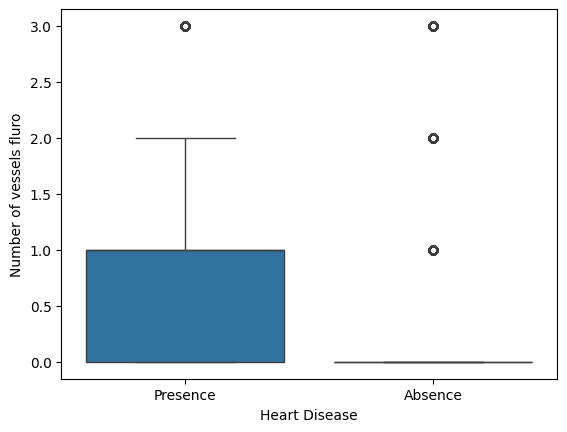

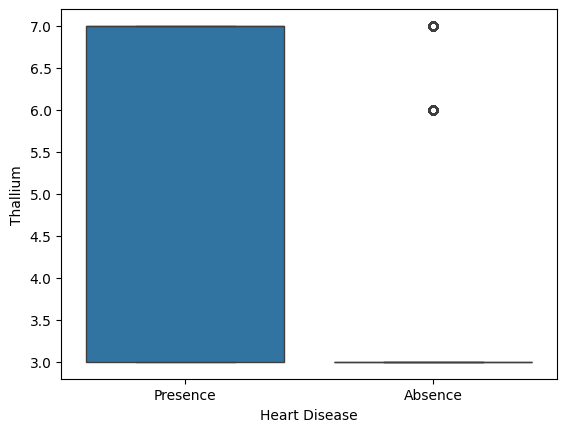

In [13]:
for col in heart_data.columns:
    if col != 'Heart Disease':
        sns.boxplot(x='Heart Disease', y=col, data=heart_data)
        plt.show()

Density Plots

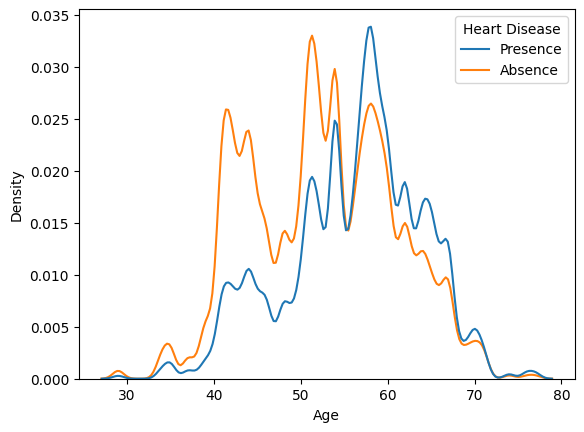

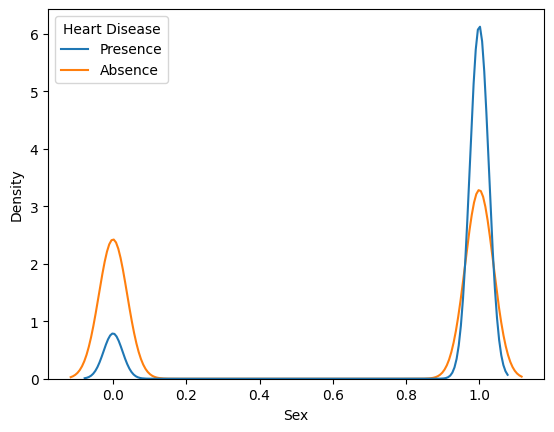

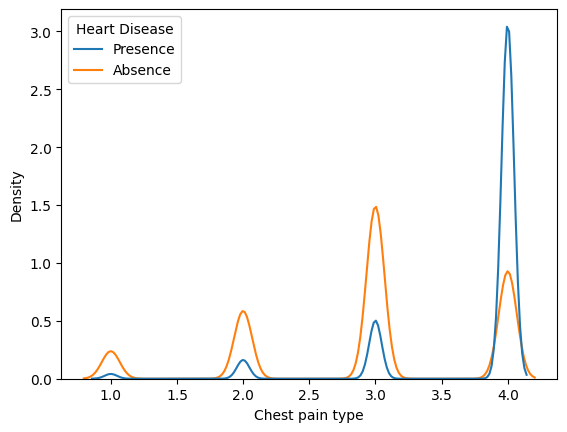

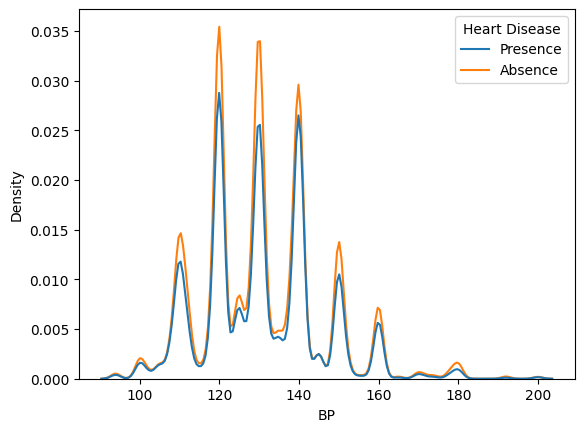

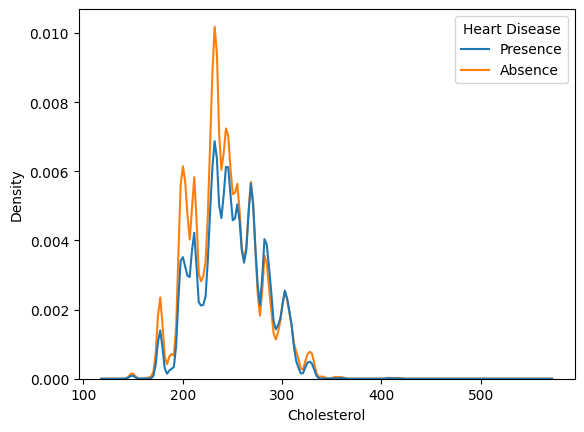

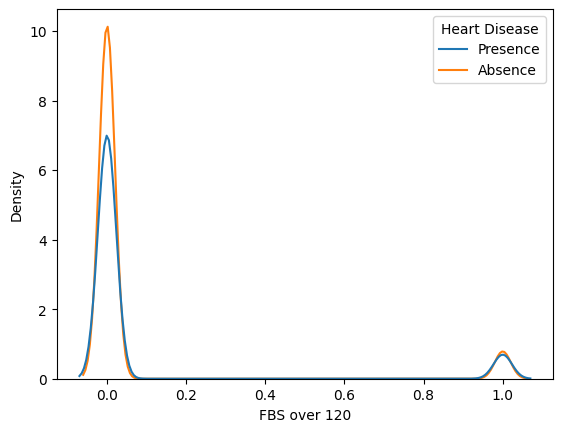

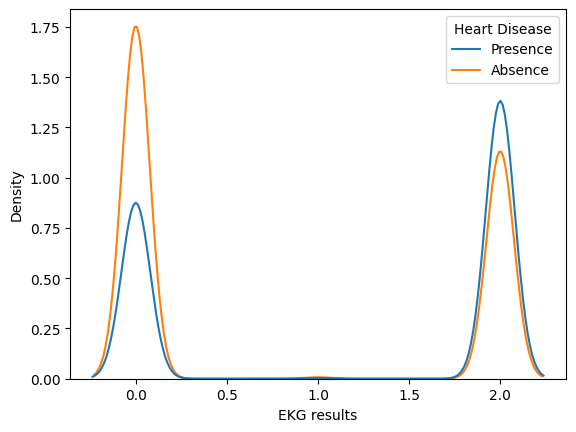

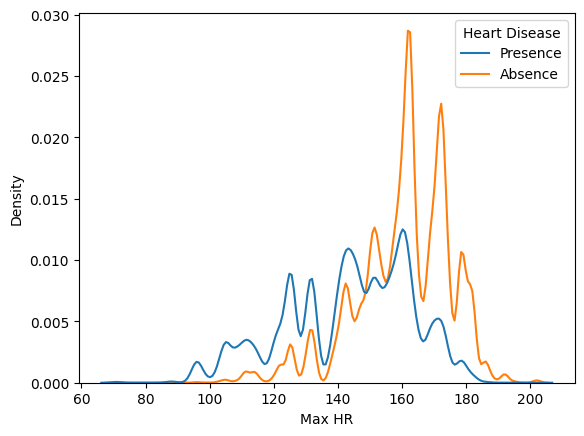

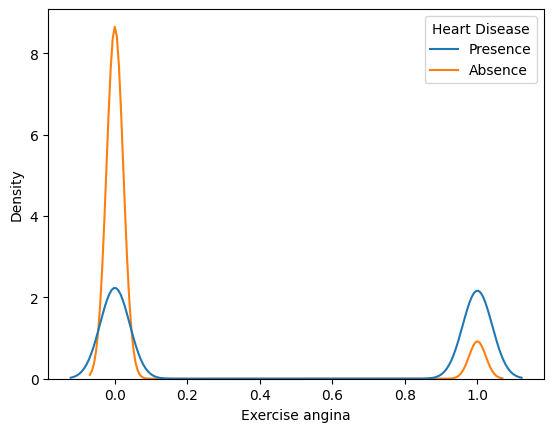

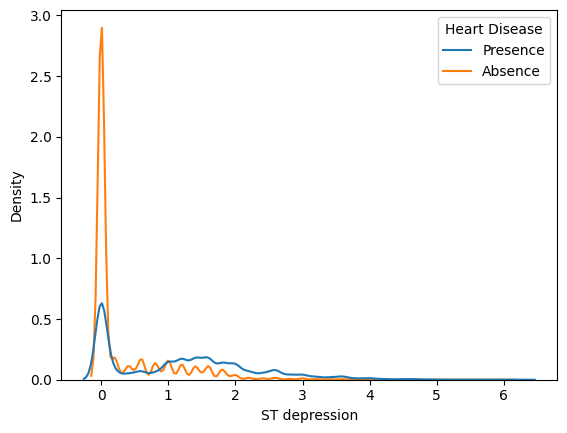

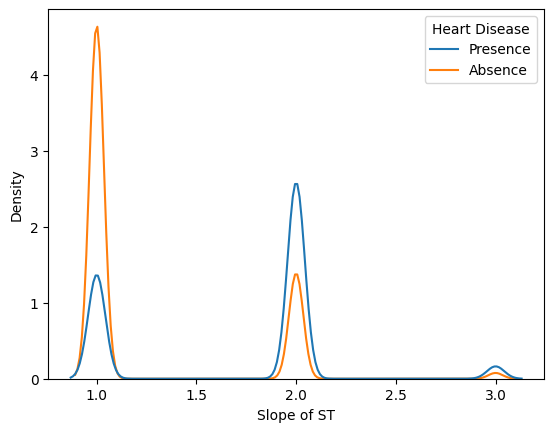

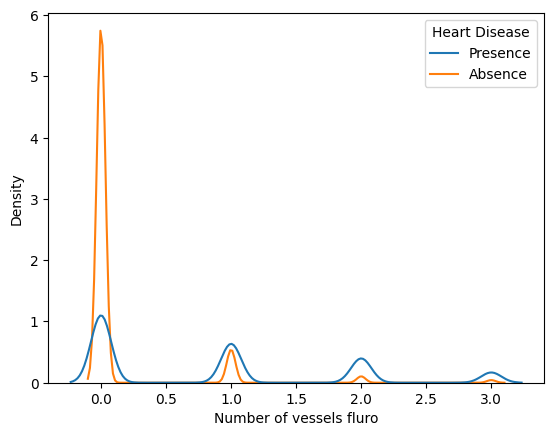

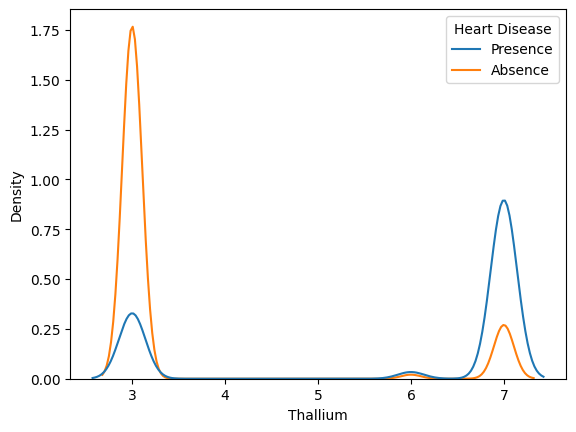

In [14]:
for col in heart_data.columns:
    if col != 'Heart Disease':
        sns.kdeplot(data=heart_data, x=col, hue='Heart Disease')
        plt.show()

Correlation Matrix

In [15]:
heart_data['Heart_Disease_numeric'] = heart_data['Heart Disease'].map({
    'Absence': 0,
    'Presence': 1
})

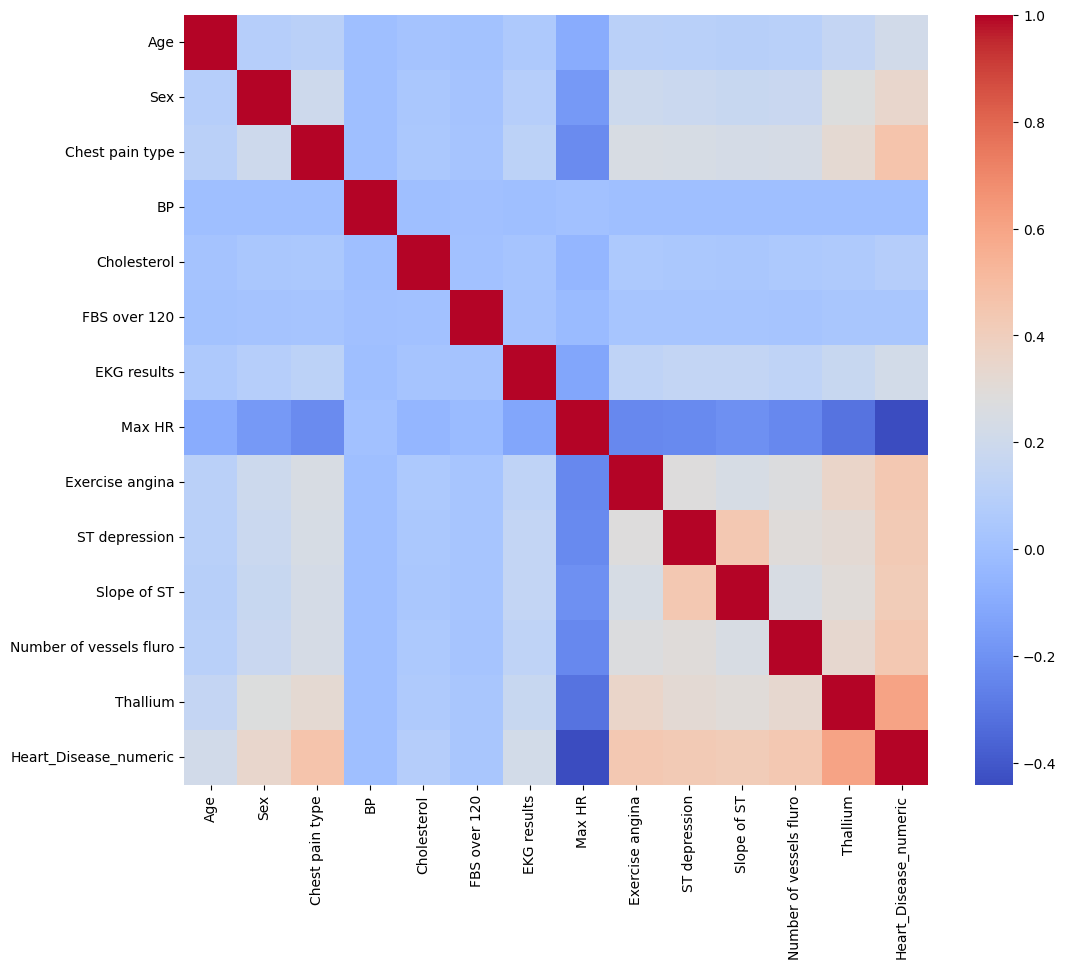

In [16]:
corr = heart_data.corr(numeric_only=True)

plt.figure(figsize=(12,10))
sns.heatmap(corr, cmap='coolwarm')
plt.show()

In [17]:
corr['Heart_Disease_numeric'].sort_values(ascending=False)

Heart_Disease_numeric      1.000000
Thallium                   0.605776
Chest pain type            0.460684
Exercise angina            0.441864
Number of vessels fluro    0.438604
ST depression              0.430641
Slope of ST                0.415050
Sex                        0.342446
EKG results                0.218961
Age                        0.212091
Cholesterol                0.082753
FBS over 120               0.033570
BP                        -0.005181
Max HR                    -0.440985
Name: Heart_Disease_numeric, dtype: float64

Feature vs Target Statistical Testing

In [18]:
from scipy.stats import ttest_ind

for col in heart_data.columns:
    if col not in ['Heart Disease','Heart_Disease_numeric']:
        group0 = heart_data[heart_data['Heart_Disease_numeric']==0][col]
        group1 = heart_data[heart_data['Heart_Disease_numeric']==1][col]
        stat, p = ttest_ind(group0, group1)
        print(col, p)

Age 0.0
Sex 0.0
Chest pain type 0.0
BP 3.91682775270394e-05
Cholesterol 0.0
FBS over 120 1.6502091885228302e-156
EKG results 0.0
Max HR 0.0
Exercise angina 0.0
ST depression 0.0
Slope of ST 0.0
Number of vessels fluro 0.0
Thallium 0.0


All the features show statistically significant differences between Heart Disease Presence and Absense indicated by value small p-value. This means that each feature is associated with target, though it doesn't guarantee equal predictive strength for modeling.

### Baseline Implementation - Logistic Regression

In [19]:
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix
from lightgbm import LGBMClassifier

In [20]:
heart_data['Heart Disease'] = heart_data['Heart Disease'].map({
    'Absence': 0,
    'Presence': 1
})

In [21]:
heart_data['Heart Disease'].value_counts()

Heart Disease
0    347546
1    282454
Name: count, dtype: int64

In [22]:
X = heart_data.drop(columns=['Heart Disease', 'Heart_Disease_numeric'])
y = heart_data['Heart Disease']
X_test_final = test_data.copy()

In [23]:
X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

Feature Scaling

In [24]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test_final)


In [25]:
logistic_regression = LogisticRegression(max_iter=2000, class_weight='balanced', random_state=42)

logistic_regression.fit(X_train_scaled, y_train)

LogisticRegression(class_weight='balanced', max_iter=2000, random_state=42)

In [26]:
val_probs = logistic_regression.predict_proba(X_val_scaled)[:, 1]
val_auc = roc_auc_score(y_val, val_probs)

print("Validation ROC-AUC:", val_auc)

Validation ROC-AUC: 0.9515563899340904


#### Hyperparameter Tuning for Logistic Regression

In [28]:
param_grid = {
    "C": [0.001, 0.01, 0.1, 1, 5, 10, 50, 100],
    "penalty": ["l2", "l1"],
    "solver": ["lbfgs", "liblinear"], 
}

grid = GridSearchCV(
    LogisticRegression(max_iter=2000),
    param_grid,
    scoring="roc_auc",
    cv=5,
    n_jobs=-1
)

grid.fit(X_train_scaled, y_train)

print(grid.best_params_)
print(grid.best_score_)

/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py:528: FitFailedWarning: 
40 fits failed out of a total of 160.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
40 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/usr/local/lib/python3.12/dist-packages/sklearn/base.py", line 1389, in wrapper
    return fit_method(estimator, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py", line 1193, in fit
    solver = _check_solve

{'C': 0.001, 'penalty': 'l2', 'solver': 'liblinear'}
0.9502245957290455


In [29]:
model_lr = grid.best_estimator_

In [30]:
val_probs = model_lr.predict_proba(X_val_scaled)[:, 1]
val_auc = roc_auc_score(y_val, val_probs)

print("Validation ROC-AUC:", val_auc)

Validation ROC-AUC: 0.9515538472976368


### LightGBM Classifier Implementation

In [31]:
lgbm = LGBMClassifier(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=-1,
    num_leaves=31,
    random_state=42
)

lgbm.fit(X_train, y_train)

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 225963, number of negative: 278037
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.039410 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 418
[LightGBM] [Info] Number of data points in the train set: 504000, number of used features: 13
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.448339 -> initscore=-0.207383
[LightGBM] [Info] Start training from score -0.207383


LGBMClassifier(learning_rate=0.05, n_estimators=500, random_state=42)

In [32]:
val_probs = lgbm.predict_proba(X_val)[:,1]
val_auc = roc_auc_score(y_val, val_probs)

print("Validation ROC-AUC:", val_auc)

Validation ROC-AUC: 0.9559846794785147


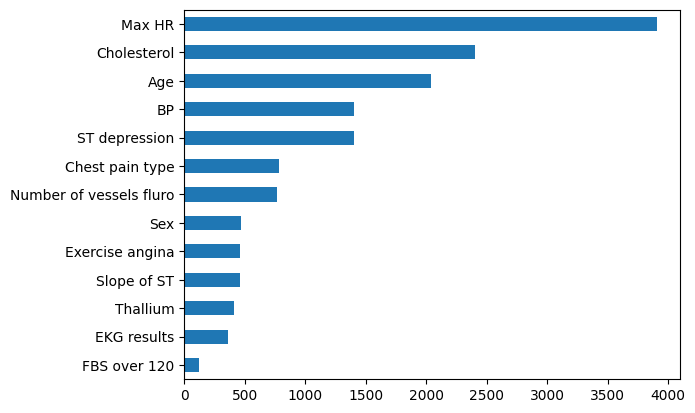

In [33]:
imp = pd.Series(lgbm.feature_importances_, index=X.columns)
imp.sort_values().tail(15).plot(kind='barh')
plt.show()

In [34]:
param_dist = {
    "n_estimators": [300,500,800],
    "learning_rate": [0.01,0.03,0.05,0.1],
    "num_leaves": [31,63,127],
    "max_depth": [-1,5,10],
    "min_child_samples": [20,50,100],
    "subsample": [0.7,0.8,0.9,1.0],
    "colsample_bytree": [0.7,0.8,0.9,1.0]
}

search = RandomizedSearchCV(
    LGBMClassifier(random_state=42),
    param_dist,
    n_iter=30,
    scoring="roc_auc",
    cv=5,
    n_jobs=-1
)

search.fit(X_train, y_train)

print(search.best_params_)
print(search.best_score_)

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 180771, number of negative: 222429
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.130863 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 418
[LightGBM] [Info] Number of data points in the train set: 403200, number of used features: 13
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.448341 -> initscore=-0.207377
[LightGBM] [Info] Start training from score -0.207377
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 180770, number of negative: 222430
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.086330 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `for

In [35]:
best_lgbm = search.best_estimator_

In [36]:
val_probs = best_lgbm.predict_proba(X_val)[:,1]
val_auc = roc_auc_score(y_val, val_probs)

print("Validation ROC-AUC:", val_auc)

Validation ROC-AUC: 0.9561194398472367


In [37]:
best_lgbm.fit(X,y)

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 282454, number of negative: 347546
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.042416 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 417
[LightGBM] [Info] Number of data points in the train set: 630000, number of used features: 13
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.448340 -> initscore=-0.207381
[LightGBM] [Info] Start training from score -0.207381
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, b

LGBMClassifier(colsample_bytree=0.7, learning_rate=0.05, max_depth=5,
               min_child_samples=100, n_estimators=500, num_leaves=127,
               random_state=42)

In [ ]:
# test_probs = model_lr.predict_proba(X_test_scaled)[:,1]

In [ ]:
# test_probs = lgbm.predict_proba(X_test_final)[:,1]

In [38]:
test_probs = best_lgbm.predict_proba(X_test_final)[:,1]

In [39]:
submission = pd.DataFrame({
    'id': test_data.index,
    'Heart Disease': test_probs
})

submission.to_csv("submission.csv", index=False)